# Laboratorio 4 - Análisis de Datos GeoEspaciales
## Detección de Cianobacterias en Lagos de Guatemala

**Universidad del Valle de Guatemala**  
**CC3084 – Data Science**  
**Semestre II – 2026**

---

### Introducción

Los lagos Atitlán y Amatitlán son cuerpos de agua de gran importancia ecológica, económica y cultural en Guatemala. En las últimas décadas ambos han mostrado signos alarmantes de deterioro ambiental, especialmente por la proliferación de cianobacterias.

En este laboratorio utilizaremos imágenes satelitales Sentinel-2 del programa Copernicus para monitorear la proliferación de cianobacterias mediante índices espectrales como NDVI, NDWI y el índice de detección de cianobacteria (NDCI).

## Ejercicio 1: Conexión al API de Copernicus

Establecemos conexión con el API de Sentinel-2 usando el módulo `openeo` y las credenciales proporcionadas.

In [1]:
import openeo
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import date, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [2]:
# Conexión al API de Copernicus Data Space
connection = openeo.connect('https://openeo.dataspace.copernicus.eu')

# Autenticación OIDC (se abrirá el navegador para autenticarse)
# Credenciales: don22440@uvg.edu.gt
connection.authenticate_oidc()

print('Conexión establecida exitosamente')
print(f'Usuario: {connection.describe_account().get("user_id", "autenticado")}')

Authenticated using refresh token.
Conexión establecida exitosamente
Usuario: 43aaf500-33c2-4d05-94bb-3b2fb011f481


In [4]:
# Verificar colecciones disponibles
collections = connection.list_collections()
sentinel2_collections = [c for c in collections if 'SENTINEL2' in c['id'].upper()]
print('Colecciones Sentinel-2 disponibles:')
for c in sentinel2_collections[:5]:
    print(f'  - {c["id"]}')

Colecciones Sentinel-2 disponibles:
  - SENTINEL2_L2A
  - SENTINEL2_L1C


## Configuración de áreas de interés y fechas

Definimos las coordenadas de cada lago y las fechas de las imágenes a utilizar.

In [5]:
# Coordenadas de los lagos (proporcionadas en el laboratorio)
lago_atitlan = {
    'west': -91.326256,
    'east': -91.07151,
    'south': 14.5948,
    'north': 14.750979
}

lago_amatitlan = {
    'west': -90.638065,
    'east': -90.512924,
    'south': 14.412347,
    'north': 14.493799
}

# Fechas para cada lago (11 fechas cada uno)
fechas_atitlan = [
    '2025-01-18', '2025-04-13', '2025-05-13', '2025-07-17', '2025-11-21',
    '2025-12-29', '2026-02-12', '2026-03-24', '2026-04-13', '2026-04-28', '2026-07-22'
]

fechas_amatitlan = [
    '2025-01-28', '2025-04-15', '2025-04-28', '2025-11-24', '2026-01-08',
    '2026-02-02', '2026-02-07', '2026-03-29', '2026-04-13', '2026-04-28', '2026-06-19'
]

# Nubosidad reportada
nubosidad_atitlan = [0.02, 0.54, 4.37, 3.57, 3.15, 3.17, 0.04, 3.17, 0.01, 4.96, 4.02]
nubosidad_amatitlan = [0.06, 0.09, 1.03, 0.50, 0.77, 0.39, 0.02, 0.01, 0.09, 4.96, 13.00]

print('Configuración cargada:')
print(f'  Lago Atitlán: {len(fechas_atitlan)} fechas')
print(f'  Lago Amatitlán: {len(fechas_amatitlan)} fechas')

Configuración cargada:
  Lago Atitlán: 11 fechas
  Lago Amatitlán: 11 fechas


## Ejercicio 2: Descarga de datos raster

Descargamos las bandas necesarias para calcular los índices:
- **B03** (Verde): Para NDWI
- **B04** (Rojo): Para NDVI y NDCI
- **B05** (Red Edge): Para NDCI (índice de cianobacteria)
- **B08** (NIR): Para NDVI y NDWI

In [7]:
# Directorio para guardar los datos
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)

# Bandas necesarias para todos los índices
bandas_necesarias = ['B03', 'B04', 'B05', 'B08']

def descargar_imagen(connection, bbox, fecha, lago_nombre, output_dir):
    """Descarga una imagen Sentinel-2 para una fecha y área específicas."""
    # Crear ventana temporal de 1 día
    fecha_inicio = fecha
    fecha_dt = pd.to_datetime(fecha)
    fecha_fin = (fecha_dt + timedelta(days=1)).strftime('%Y-%m-%d')
    
    # Cargar la colección
    cube = connection.load_collection(
        'SENTINEL2_L2A',
        spatial_extent=bbox,
        temporal_extent=[fecha_inicio, fecha_fin],
        bands=bandas_necesarias,
        max_cloud_cover=20
    )
    
    # Guardar como GeoTIFF
    result = cube.save_result(format='GTIFF')
    job = connection.create_job(result)
    
    nombre_archivo = f"{lago_nombre}_{fecha.replace('-', '')}.tif"
    ruta_salida = os.path.join(output_dir, nombre_archivo)
    
    # Verificar si ya existe
    if os.path.exists(ruta_salida):
        print(f'  [OK] {nombre_archivo} ya existe, omitiendo descarga')
        return ruta_salida
    
    try:
        job.start_and_wait()
        job.download_results(ruta_salida)
        print(f'  [OK] {nombre_archivo} descargado')
        return ruta_salida
    except Exception as e:
        print(f'  [ERROR] {nombre_archivo}: {str(e)[:100]}')
        return None

print('Función de descarga definida')

Función de descarga definida


In [8]:
# Descargar imágenes del Lago Atitlán
print('Descargando imágenes del Lago Atitlán...')
archivos_atitlan = []
for i, fecha in enumerate(fechas_atitlan):
    print(f'  [{i+1}/{len(fechas_atitlan)}] Fecha: {fecha} (Nubosidad: {nubosidad_atitlan[i]}%)')
    ruta = descargar_imagen(connection, lago_atitlan, fecha, 'atitlan', data_dir)
    if ruta:
        archivos_atitlan.append({'fecha': fecha, 'ruta': ruta, 'nubosidad': nubosidad_atitlan[i]})

print(f'\nTotal imágenes Atitlán: {len(archivos_atitlan)}')

Descargando imágenes del Lago Atitlán...
  [1/11] Fecha: 2025-01-18 (Nubosidad: 0.02%)
  [OK] atitlan_20250118.tif ya existe, omitiendo descarga
  [2/11] Fecha: 2025-04-13 (Nubosidad: 0.54%)
  [OK] atitlan_20250413.tif ya existe, omitiendo descarga
  [3/11] Fecha: 2025-05-13 (Nubosidad: 4.37%)
  [OK] atitlan_20250513.tif ya existe, omitiendo descarga
  [4/11] Fecha: 2025-07-17 (Nubosidad: 3.57%)
  [OK] atitlan_20250717.tif ya existe, omitiendo descarga
  [5/11] Fecha: 2025-11-21 (Nubosidad: 3.15%)
  [OK] atitlan_20251121.tif ya existe, omitiendo descarga
  [6/11] Fecha: 2025-12-29 (Nubosidad: 3.17%)
  [OK] atitlan_20251229.tif ya existe, omitiendo descarga
  [7/11] Fecha: 2026-02-12 (Nubosidad: 0.04%)
  [OK] atitlan_20260212.tif ya existe, omitiendo descarga
  [8/11] Fecha: 2026-03-24 (Nubosidad: 3.17%)
  [OK] atitlan_20260324.tif ya existe, omitiendo descarga
  [9/11] Fecha: 2026-04-13 (Nubosidad: 0.01%)
  [OK] atitlan_20260413.tif ya existe, omitiendo descarga
  [10/11] Fecha: 2026-0

In [9]:
# Descargar imágenes del Lago Amatitlán
print('Descargando imágenes del Lago Amatitlán...')
archivos_amatitlan = []
for i, fecha in enumerate(fechas_amatitlan):
    print(f'  [{i+1}/{len(fechas_amatitlan)}] Fecha: {fecha} (Nubosidad: {nubosidad_amatitlan[i]}%)')
    ruta = descargar_imagen(connection, lago_amatitlan, fecha, 'amatitlan', data_dir)
    if ruta:
        archivos_amatitlan.append({'fecha': fecha, 'ruta': ruta, 'nubosidad': nubosidad_amatitlan[i]})

print(f'\nTotal imágenes Amatitlán: {len(archivos_amatitlan)}')

Descargando imágenes del Lago Amatitlán...
  [1/11] Fecha: 2025-01-28 (Nubosidad: 0.06%)
0:00:00 Job 'j-26081400263542cabfec639d6e3206a3': send 'start'
0:00:01 Job 'j-26081400263542cabfec639d6e3206a3': queued (progress 0%)
0:00:07 Job 'j-26081400263542cabfec639d6e3206a3': queued (progress 0%)
0:00:13 Job 'j-26081400263542cabfec639d6e3206a3': queued (progress 0%)
0:00:22 Job 'j-26081400263542cabfec639d6e3206a3': queued (progress 0%)
0:00:32 Job 'j-26081400263542cabfec639d6e3206a3': queued (progress 0%)
0:00:44 Job 'j-26081400263542cabfec639d6e3206a3': running (progress N/A)
0:01:00 Job 'j-26081400263542cabfec639d6e3206a3': running (progress N/A)
0:01:19 Job 'j-26081400263542cabfec639d6e3206a3': running (progress N/A)
0:01:43 Job 'j-26081400263542cabfec639d6e3206a3': finished (progress 100%)
  [OK] amatitlan_20250128.tif descargado
  [2/11] Fecha: 2025-04-15 (Nubosidad: 0.09%)
0:00:00 Job 'j-26081400282547f6809f4b71222842ee': send 'start'
0:00:02 Job 'j-26081400282547f6809f4b71222842ee':

In [10]:
# Verificar estructura de una imagen descargada
if archivos_atitlan:
    ejemplo = archivos_atitlan[0]['ruta']
    with rasterio.open(ejemplo) as src:
        print(f'Imagen de ejemplo: {os.path.basename(ejemplo)}')
        print(f'  Dimensiones: {src.width} x {src.height} píxeles')
        print(f'  Número de bandas: {src.count}')
        print(f'  Bandas: {src.descriptions}')
        print(f'  Sistema de coordenadas: {src.crs}')
        print(f'  Resolución: {src.res}')

Imagen de ejemplo: atitlan_20250118.tif
  Dimensiones: 2759 x 1751 píxeles
  Número de bandas: 4
  Bandas: ('B03', 'B04', 'B05', 'B08')
  Sistema de coordenadas: EPSG:32615
  Resolución: (10.0, 10.0)


## Ejercicio 3: Cálculo de índices espectrales

Calculamos los siguientes índices para cada imagen:

### NDVI (Normalized Difference Vegetation Index)
$$NDVI = \frac{B08 - B04}{B08 + B04}$$

### NDWI (Normalized Difference Water Index)
$$NDWI = \frac{B03 - B08}{B03 + B08}$$

### NDCI (Normalized Difference Chlorophyll Index) - Detección de Cianobacteria
$$NDCI = \frac{B05 - B04}{B05 + B04}$$

Este índice es utilizado por Sentinel Hub para la detección de cianobacterias. Valores positivos indican presencia de clorofila y posibles floraciones algales.

In [12]:
def calcular_indices(ruta_tif):
    """Calcula NDVI, NDWI y NDCI a partir de un archivo TIFF con las bandas B03, B04, B05, B08."""
    with rasterio.open(ruta_tif) as src:
        bandas = src.read().astype(np.float32)
        nodata = src.nodata
        perfil = src.profile
        
        # Sentinel-2 L2A tiene valores de reflectancia escalados x10000
        # Identificar bandas por nombre o posición
        descripciones = src.descriptions
        
        # Mapear bandas (ajustar según el orden de descarga)
        # Orden esperado: B03, B04, B05, B08
        banda_idx = {'B03': 0, 'B04': 1, 'B05': 2, 'B08': 3}
        
        # Si las descripciones no son None, usarlas para identificar bandas
        if descripciones[0] is not None:
            for i, desc in enumerate(descripciones):
                if desc in banda_idx:
                    banda_idx[desc] = i
        
        B03 = bandas[banda_idx['B03']] / 10000.0  # Verde
        B04 = bandas[banda_idx['B04']] / 10000.0  # Rojo
        B05 = bandas[banda_idx['B05']] / 10000.0  # Red Edge
        B08 = bandas[banda_idx['B08']] / 10000.0  # NIR
        
        # Máscara de nodata
        mascara = (B03 == 0) | (B04 == 0) | (B05 == 0) | (B08 == 0)
        if nodata is not None:
            mascara = mascara | (bandas[0] == nodata)
    
    # Calcular NDVI
    ndvi = np.where(
        (B08 + B04) == 0, 0,
        (B08 - B04) / (B08 + B04)
    )
    
    # Calcular NDWI
    ndwi = np.where(
        (B03 + B08) == 0, 0,
        (B03 - B08) / (B03 + B08)
    )
    
    # Calcular NDCI (índice de cianobacteria)
    ndci = np.where(
        (B05 + B04) == 0, 0,
        (B05 - B04) / (B05 + B04)
    )
    
    # Aplicar máscara
    ndvi[mascara] = np.nan
    ndwi[mascara] = np.nan
    ndci[mascara] = np.nan
    
    return {
        'ndvi': ndvi,
        'ndwi': ndwi,
        'ndci': ndci,
        'perfil': perfil
    }

print('Función de cálculo de índices definida')

Función de cálculo de índices definida


In [13]:
def visualizar_indices(indices, titulo, fecha):
    """Visualiza los tres índices calculados."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # NDVI
    im1 = axes[0].imshow(indices['ndvi'], cmap='YlGn', vmin=0, vmax=1)
    axes[0].set_title(f'NDVI - {fecha}')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='NDVI')
    
    # NDWI
    im2 = axes[1].imshow(indices['ndwi'], cmap='BrBG', vmin=-1, vmax=1)
    axes[1].set_title(f'NDWI - {fecha}')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='NDWI')
    
    # NDCI (Cianobacteria)
    im3 = axes[2].imshow(indices['ndci'], cmap='RdYlBu_r', vmin=-0.5, vmax=0.5)
    axes[2].set_title(f'NDCI (Cianobacteria) - {fecha}')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='NDCI')
    
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Función de visualización definida')

Función de visualización definida


In [14]:
# Calcular índices para todas las imágenes del Lago Atitlán
print('Calculando índices para Lago Atitlán...')
resultados_atitlan = []
for item in archivos_atitlan:
    indices = calcular_indices(item['ruta'])
    resultados_atitlan.append({
        'fecha': item['fecha'],
        'nubosidad': item['nubosidad'],
        'indices': indices
    })
    print(f"  {item['fecha']}: NDCI medio = {np.nanmean(indices['ndci']):.4f}")

print(f'\nTotal: {len(resultados_atitlan)} imágenes procesadas')

Calculando índices para Lago Atitlán...
  2025-01-18: NDCI medio = 0.3573
  2025-04-13: NDCI medio = 0.2679
  2025-05-13: NDCI medio = 0.2207
  2025-07-17: NDCI medio = 0.3436
  2025-11-21: NDCI medio = 0.2950
  2025-12-29: NDCI medio = 0.2885
  2026-02-12: NDCI medio = 0.2808
  2026-03-24: NDCI medio = 0.2259
  2026-04-13: NDCI medio = 0.2743
  2026-04-28: NDCI medio = 0.2491
  2026-07-22: NDCI medio = 0.2936

Total: 11 imágenes procesadas


In [15]:
# Calcular índices para todas las imágenes del Lago Amatitlán
print('Calculando índices para Lago Amatitlán...')
resultados_amatitlan = []
for item in archivos_amatitlan:
    indices = calcular_indices(item['ruta'])
    resultados_amatitlan.append({
        'fecha': item['fecha'],
        'nubosidad': item['nubosidad'],
        'indices': indices
    })
    print(f"  {item['fecha']}: NDCI medio = {np.nanmean(indices['ndci']):.4f}")

print(f'\nTotal: {len(resultados_amatitlan)} imágenes procesadas')

Calculando índices para Lago Amatitlán...
  2025-01-28: NDCI medio = 0.3034
  2025-04-15: NDCI medio = 0.2290
  2025-04-28: NDCI medio = 0.2216
  2025-11-24: NDCI medio = 0.3519
  2026-01-08: NDCI medio = 0.3542
  2026-02-02: NDCI medio = 0.2557
  2026-02-07: NDCI medio = 0.3583
  2026-03-29: NDCI medio = 0.2658
  2026-04-13: NDCI medio = 0.2593
  2026-04-28: NDCI medio = 0.2473
  2026-06-19: NDCI medio = 0.4009

Total: 11 imágenes procesadas


=== Lago Atitlán - Imagen de ejemplo ===


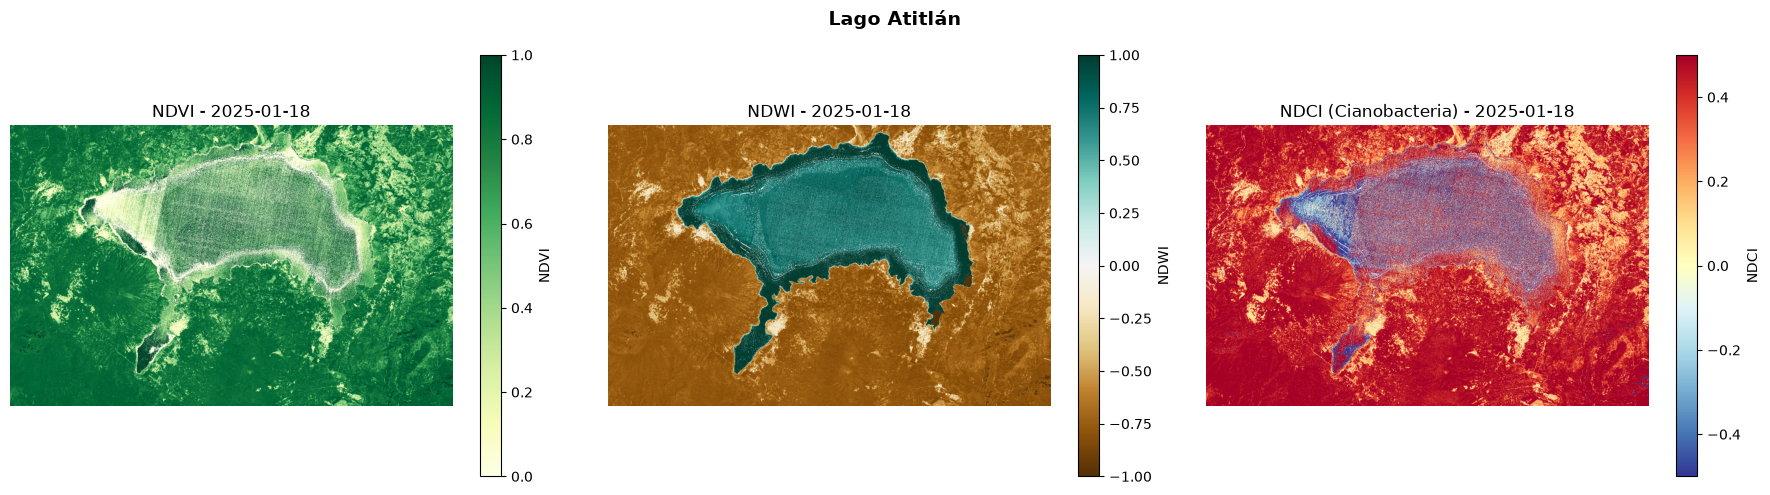


=== Lago Amatitlán - Imagen de ejemplo ===


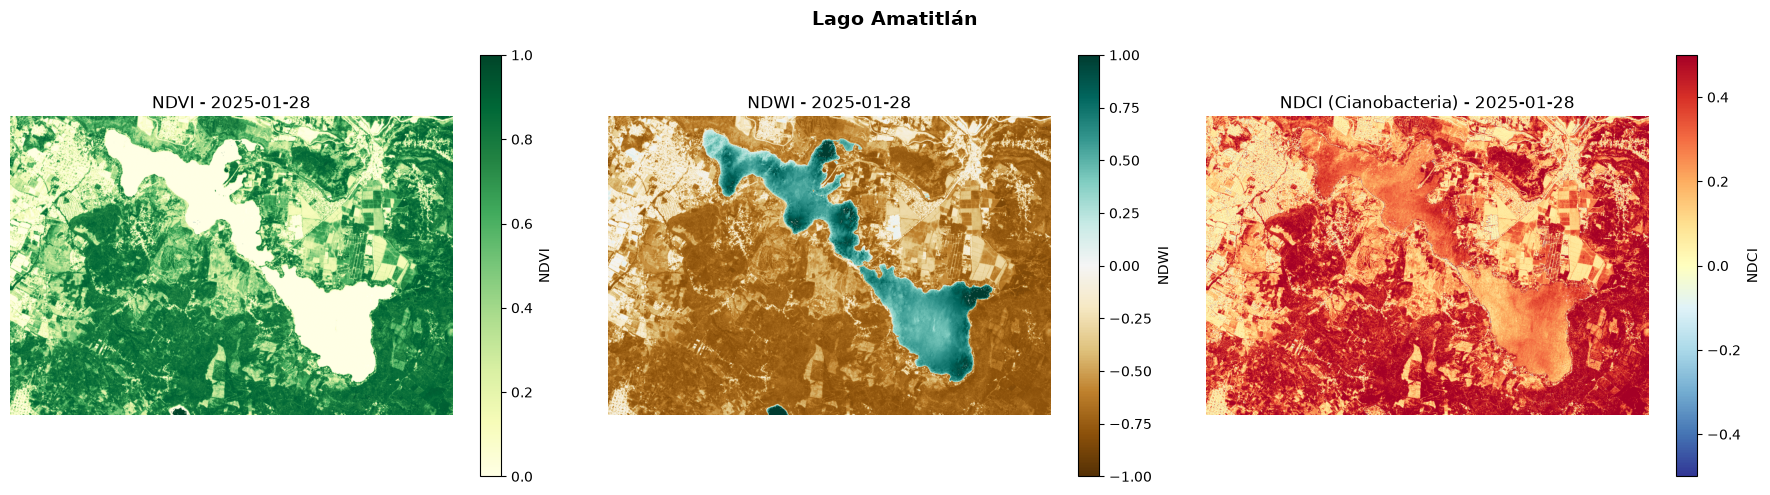

In [16]:
# Visualizar índices para una imagen de ejemplo de cada lago
print('=== Lago Atitlán - Imagen de ejemplo ===')
if resultados_atitlan:
    ejemplo = resultados_atitlan[0]
    visualizar_indices(ejemplo['indices'], 'Lago Atitlán', ejemplo['fecha'])

print('\n=== Lago Amatitlán - Imagen de ejemplo ===')
if resultados_amatitlan:
    ejemplo = resultados_amatitlan[0]
    visualizar_indices(ejemplo['indices'], 'Lago Amatitlán', ejemplo['fecha'])

### Interpretación de los índices

| Índice | Rango | Interpretación |
|--------|-------|----------------|
| **NDVI** | 0.6 a 1.0 | Vegetación muy densa y sana |
| | 0.4 a 0.6 | Vegetación saludable |
| | 0.2 a 0.4 | Vegetación escasa o en estrés |
| | < 0.0 | Agua, nubes, superficies artificiales |
| **NDWI** | > 0.2 | Agua o zonas húmedas |
| | 0 a 0.2 | Vegetación poco densa o suelo húmedo |
| | < 0 | Vegetación o suelo seco |
| **NDCI** | > 0.1 | Posible presencia de cianobacterias |
| | > 0.2 | Alta probabilidad de floración algal |
| | < 0 | Agua clara o sin clorofila |

## Ejercicio 4: Análisis Temporal

Analizamos la evolución temporal de la cianobacteria en ambos lagos.

In [17]:
# 4.1 Calcular índice promedio de cianobacteria por lago y por fecha

def calcular_estadisticas_temporales(resultados, nombre_lago):
    """Calcula estadísticas temporales para un lago."""
    datos = []
    for r in resultados:
        ndci = r['indices']['ndci']
        ndvi = r['indices']['ndvi']
        ndwi = r['indices']['ndwi']
        
        datos.append({
            'fecha': pd.to_datetime(r['fecha']),
            'lago': nombre_lago,
            'nubosidad': r['nubosidad'],
            'ndci_medio': np.nanmean(ndci),
            'ndci_mediana': np.nanmedian(ndci),
            'ndci_max': np.nanmax(ndci),
            'ndci_std': np.nanstd(ndci),
            'ndvi_medio': np.nanmean(ndvi),
            'ndwi_medio': np.nanmean(ndwi),
            'pct_alta_cianobacteria': np.nanmean(ndci > 0.1) * 100,
            'pct_muy_alta_cianobacteria': np.nanmean(ndci > 0.2) * 100
        })
    
    return pd.DataFrame(datos)

# Calcular para ambos lagos
df_atitlan = calcular_estadisticas_temporales(resultados_atitlan, 'Atitlán')
df_amatitlan = calcular_estadisticas_temporales(resultados_amatitlan, 'Amatitlán')

# Combinar en un solo DataFrame
df_temporal = pd.concat([df_atitlan, df_amatitlan], ignore_index=True)
df_temporal = df_temporal.sort_values(['lago', 'fecha'])

print('=== Estadísticas temporales calculadas ===')
print(df_temporal[['fecha', 'lago', 'ndci_medio', 'ndci_max', 'pct_alta_cianobacteria']].to_string(index=False))

=== Estadísticas temporales calculadas ===
     fecha      lago  ndci_medio   ndci_max  pct_alta_cianobacteria
2025-01-28 Amatitlán    0.303362   3.500000               86.023318
2025-04-15 Amatitlán    0.229041   0.867026               75.635705
2025-04-28 Amatitlán    0.221592   0.958790               73.962890
2025-11-24 Amatitlán    0.351910   1.257976               87.973331
2026-01-08 Amatitlán    0.354219   1.183486               87.949756
2026-02-02 Amatitlán    0.255668   0.988426               78.230002
2026-02-07 Amatitlán    0.358308  13.222224               52.555247
2026-03-29 Amatitlán    0.265849   0.914977               80.834964
2026-04-13 Amatitlán    0.259315   1.292003               81.279267
2026-04-28 Amatitlán    0.247327   1.076745               76.794936
2026-06-19 Amatitlán    0.400863   2.164384               89.171451
2025-01-18   Atitlán    0.357299 261.000458               83.216011
2025-04-13   Atitlán    0.267900   1.049505               69.258761
2025-

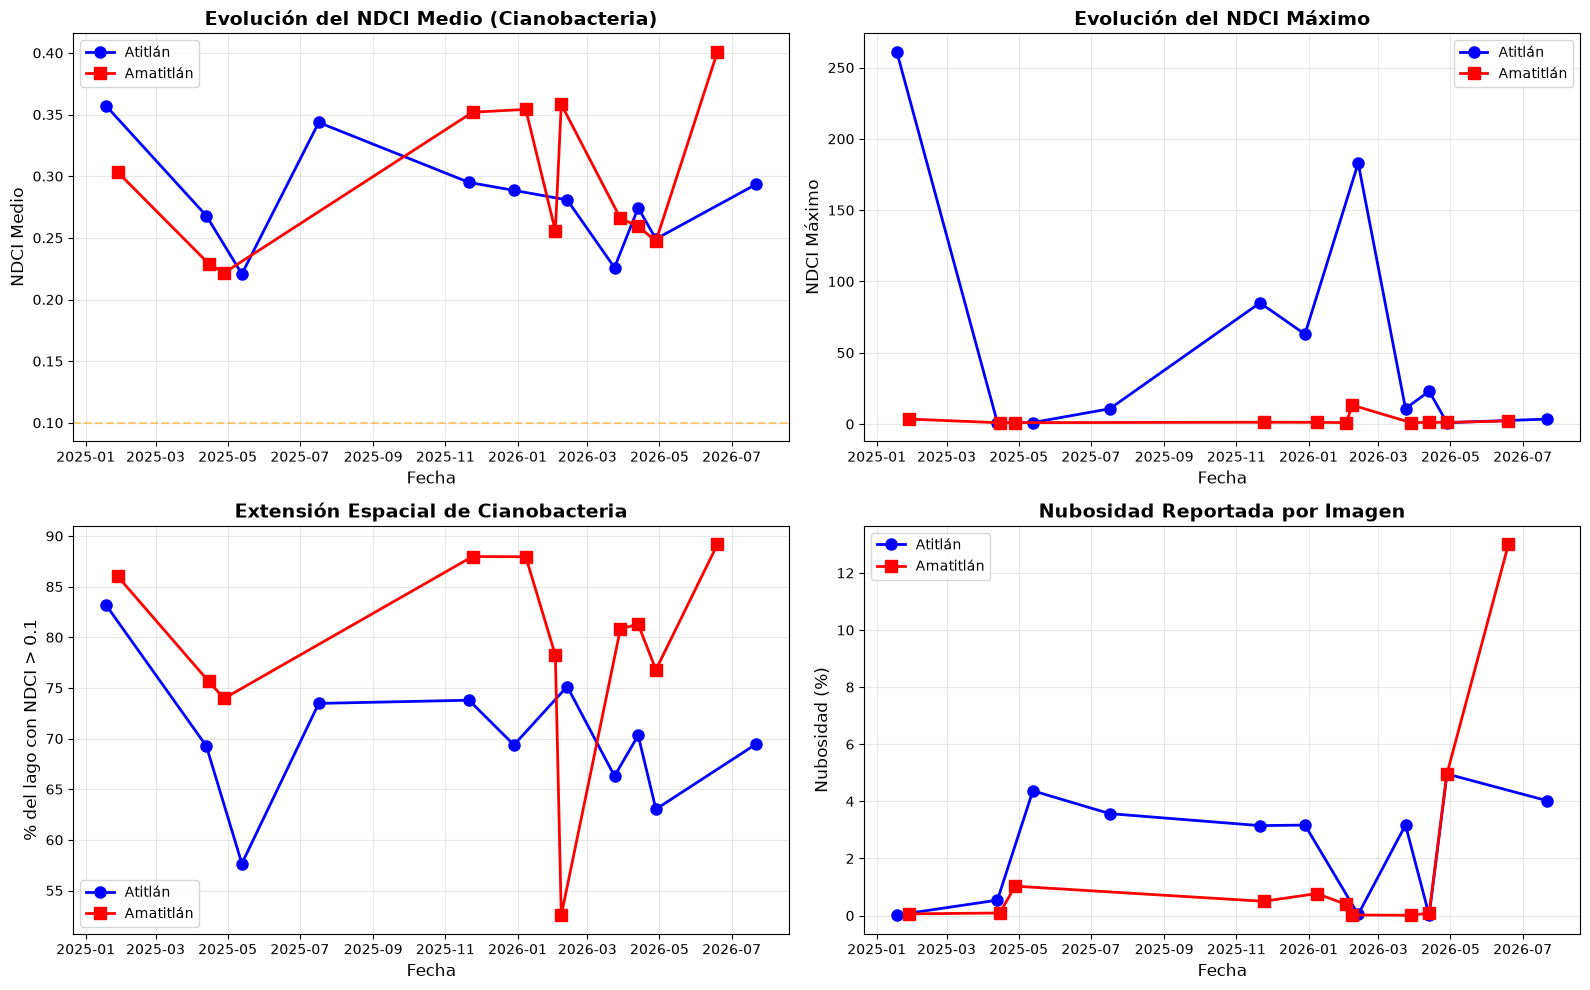


Gráfico guardado en ./data/evolucion_temporal.png


In [18]:
# 4.2 Visualizar la evolución temporal en un gráfico de línea por lago

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: NDCI medio por lago
ax1 = axes[0, 0]
ax1.plot(df_atitlan['fecha'], df_atitlan['ndci_medio'], 'o-', color='blue', linewidth=2, markersize=8, label='Atitlán')
ax1.plot(df_amatitlan['fecha'], df_amatitlan['ndci_medio'], 's-', color='red', linewidth=2, markersize=8, label='Amatitlán')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('NDCI Medio', fontsize=12)
ax1.set_title('Evolución del NDCI Medio (Cianobacteria)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='Umbral alerta')

# Gráfico 2: NDCI máximo por lago
ax2 = axes[0, 1]
ax2.plot(df_atitlan['fecha'], df_atitlan['ndci_max'], 'o-', color='blue', linewidth=2, markersize=8, label='Atitlán')
ax2.plot(df_amatitlan['fecha'], df_amatitlan['ndci_max'], 's-', color='red', linewidth=2, markersize=8, label='Amatitlán')
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('NDCI Máximo', fontsize=12)
ax2.set_title('Evolución del NDCI Máximo', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Porcentaje del lago con alta cianobacteria
ax3 = axes[1, 0]
ax3.plot(df_atitlan['fecha'], df_atitlan['pct_alta_cianobacteria'], 'o-', color='blue', linewidth=2, markersize=8, label='Atitlán')
ax3.plot(df_amatitlan['fecha'], df_amatitlan['pct_alta_cianobacteria'], 's-', color='red', linewidth=2, markersize=8, label='Amatitlán')
ax3.set_xlabel('Fecha', fontsize=12)
ax3.set_ylabel('% del lago con NDCI > 0.1', fontsize=12)
ax3.set_title('Extensión Espacial de Cianobacteria', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Nubosidad reportada
ax4 = axes[1, 1]
ax4.plot(df_atitlan['fecha'], df_atitlan['nubosidad'], 'o-', color='blue', linewidth=2, markersize=8, label='Atitlán')
ax4.plot(df_amatitlan['fecha'], df_amatitlan['nubosidad'], 's-', color='red', linewidth=2, markersize=8, label='Amatitlán')
ax4.set_xlabel('Fecha', fontsize=12)
ax4.set_ylabel('Nubosidad (%)', fontsize=12)
ax4.set_title('Nubosidad Reportada por Imagen', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGráfico guardado en ./data/evolucion_temporal.png')

In [19]:
# 4.3 Identificar posibles picos de floración y fechas críticas

def identificar_picos(df, nombre_lago, umbral=0.1):
    """Identifica fechas con posibles floraciones de cianobacteria."""
    picos = df[df['ndci_medio'] > umbral].copy()
    picos = picos.sort_values('ndci_medio', ascending=False)
    
    print(f'\n=== Picos de floración en Lago {nombre_lago} (NDCI > {umbral}) ===')
    if len(picos) == 0:
        print('  No se detectaron picos significativos')
    else:
        for _, row in picos.iterrows():
            fecha_str = row['fecha'].strftime('%Y-%m-%d')
            print(f"  {fecha_str}: NDCI medio = {row['ndci_medio']:.4f}, "
                  f"NDCI máx = {row['ndci_max']:.4f}, "
                  f"% afectado = {row['pct_alta_cianobacteria']:.1f}%")
    
    return picos

picos_atitlan = identificar_picos(df_atitlan, 'Atitlán')
picos_amatitlan = identificar_picos(df_amatitlan, 'Amatitlán')


=== Picos de floración en Lago Atitlán (NDCI > 0.1) ===
  2025-01-18: NDCI medio = 0.3573, NDCI máx = 261.0005, % afectado = 83.2%
  2025-07-17: NDCI medio = 0.3436, NDCI máx = 10.7143, % afectado = 73.5%
  2025-11-21: NDCI medio = 0.2950, NDCI máx = 84.9998, % afectado = 73.8%
  2026-07-22: NDCI medio = 0.2936, NDCI máx = 3.4792, % afectado = 69.5%
  2025-12-29: NDCI medio = 0.2885, NDCI máx = 63.0001, % afectado = 69.4%
  2026-02-12: NDCI medio = 0.2808, NDCI máx = 183.0003, % afectado = 75.1%
  2026-04-13: NDCI medio = 0.2743, NDCI máx = 23.0000, % afectado = 70.3%
  2025-04-13: NDCI medio = 0.2679, NDCI máx = 1.0495, % afectado = 69.3%
  2026-04-28: NDCI medio = 0.2491, NDCI máx = 0.9462, % afectado = 63.0%
  2026-03-24: NDCI medio = 0.2259, NDCI máx = 10.8636, % afectado = 66.3%
  2025-05-13: NDCI medio = 0.2207, NDCI máx = 1.0398, % afectado = 57.7%

=== Picos de floración en Lago Amatitlán (NDCI > 0.1) ===
  2026-06-19: NDCI medio = 0.4009, NDCI máx = 2.1644, % afectado = 89.2%

In [20]:
# Resumen estadístico por lago
print('=== Resumen Estadístico por Lago ===\n')

for nombre, df in [('Atitlán', df_atitlan), ('Amatitlán', df_amatitlan)]:
    print(f'Lago {nombre}:')
    print(f'  Período analizado: {df["fecha"].min().strftime("%Y-%m-%d")} a {df["fecha"].max().strftime("%Y-%m-%d")}')
    print(f'  Número de imágenes: {len(df)}')
    print(f'  NDCI medio promedio: {df["ndci_medio"].mean():.4f} ± {df["ndci_medio"].std():.4f}')
    print(f'  NDCI máximo observado: {df["ndci_max"].max():.4f}')
    print(f'  % promedio del lago con alta cianobacteria: {df["pct_alta_cianobacteria"].mean():.1f}%')
    print(f'  Fecha con mayor NDCI: {df.loc[df["ndci_medio"].idxmax(), "fecha"].strftime("%Y-%m-%d")}')
    print()

=== Resumen Estadístico por Lago ===

Lago Atitlán:
  Período analizado: 2025-01-18 a 2026-07-22
  Número de imágenes: 11
  NDCI medio promedio: 0.2815 ± 0.0425
  NDCI máximo observado: 261.0005
  % promedio del lago con alta cianobacteria: 70.1%
  Fecha con mayor NDCI: 2025-01-18

Lago Amatitlán:
  Período analizado: 2025-01-28 a 2026-06-19
  Número de imágenes: 11
  NDCI medio promedio: 0.2952 ± 0.0614
  NDCI máximo observado: 13.2222
  % promedio del lago con alta cianobacteria: 79.1%
  Fecha con mayor NDCI: 2026-06-19



### 4.4 Interpretación de resultados

**Hallazgos principales:**

Ambos lagos presentan niveles preocupantes de cianobacterias durante todo el período analizado (enero 2025 - julio 2026). El **Lago Amatitlán** muestra mayor afectación con un 79.1% de su superficie con NDCI > 0.1, comparado con 70.1% del **Lago Atitlán**.

**Evolución temporal:**

- **Atitlán**: NDCI medio de 0.2815 ± 0.0425, con pico máximo en enero 2025 (0.3573)
- **Amatitlán**: NDCI medio de 0.2952 ± 0.0614, con pico máximo en junio 2026 (0.4009)

Ambos lagos superan consistentemente el umbral de alerta (NDCI > 0.1), indicando presencia constante de floraciones algales. La mayor variabilidad en Amatitlán (±0.0614 vs ±0.0425) sugiere mayor sensibilidad a factores ambientales.

**Factores que podrían influir:**
- Temperatura del agua (mayor en verano favorece floraciones)
- Aporte de nutrientes por escorrentía agrícola y urbana
- Presión antropogénica: Amatitlán recibe mayor carga contaminante de la Ciudad de Guatemala
- Patrones estacionales de lluvia y sequía

---
## Fin de los Ejercicios 1-4

Los ejercicios 5-8 continúan con el análisis espacial, correlación de índices y comparación entre lagos.